In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.preprocessing import LabelBinarizer, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, f1_score

In [42]:
df = pd.read_pickle(
    filepath_or_buffer='data/churndata.pkl'
)
df.head()

,id,months,offer,phone,multiple,internet_type,gb_mon,security,backup,protection,...,unlimited,contract,paperless,payment,monthly,total_revenue,satisfaction,churn_value,churn_score,cltv
0,8779-QRDMV,1,None,No,No,DSL,8,No,No,Yes,...,No,Month-to-Month,Yes,Bank Withdrawal,39.65,59.65,3,1,91,5433
1,7495-OOKFY,8,Offer E,Yes,Yes,Fiber Optic,17,No,Yes,No,...,Yes,Month-to-Month,Yes,Credit Card,80.65,1024.10,3,1,69,5302
2,1658-BYGOY,18,Offer D,Yes,Yes,Fiber Optic,52,No,No,No,...,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1910.88,2,1,81,3179
3,4598-XLKNJ,25,Offer C,Yes,No,Fiber Optic,12,No,Yes,Yes,...,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2995.07,2,1,88,5337
4,4846-WHAFZ,37,Offer C,Yes,Yes,Fiber Optic,14,No,No,No,...,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,3102.36,2,1,67,2793


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             7043 non-null   object 
 1   months         7043 non-null   int64  
 2   offer          7043 non-null   object 
 3   phone          7043 non-null   object 
 4   multiple       7043 non-null   object 
 5   internet_type  7043 non-null   object 
 6   gb_mon         7043 non-null   int64  
 7   security       7043 non-null   object 
 8   backup         7043 non-null   object 
 9   protection     7043 non-null   object 
 10  support        7043 non-null   object 
 11  unlimited      7043 non-null   object 
 12  contract       7043 non-null   object 
 13  paperless      7043 non-null   object 
 14  payment        7043 non-null   object 
 15  monthly        7043 non-null   float64
 16  total_revenue  7043 non-null   float64
 17  satisfaction   7043 non-null   int64  
 18  churn_value  

In [5]:
df.isnull().sum()

id               0
months           0
offer            0
phone            0
multiple         0
internet_type    0
gb_mon           0
security         0
backup           0
protection       0
support          0
unlimited        0
contract         0
paperless        0
payment          0
monthly          0
total_revenue    0
satisfaction     0
churn_value      0
churn_score      0
cltv             0
dtype: int64

In [6]:
df.columns

Index(['id', 'months', 'offer', 'phone', 'multiple', 'internet_type', 'gb_mon',
       'security', 'backup', 'protection', 'support', 'unlimited', 'contract',
       'paperless', 'payment', 'monthly', 'total_revenue', 'satisfaction',
       'churn_value', 'churn_score', 'cltv'],
      dtype='object')

In [7]:
df.drop(
    columns=['id', 'phone', 'total_revenue', 'churn_score', 'cltv'],
    axis=1,
    inplace=True
)
df.shape


(7043, 16)

In [8]:
round(df.describe(),2)

,months,gb_mon,monthly,satisfaction,churn_value
count,7043.00,7043.00,7043.00,7043.00,7043.00
mean,32.39,20.52,64.76,3.24,0.27
std,24.54,20.42,30.09,1.20,0.44
min,1.00,0.00,18.25,1.00,0.00
25%,9.00,3.00,35.50,3.00,0.00
50%,29.00,17.00,70.35,3.00,0.00
75%,55.00,27.00,89.85,4.00,1.00
max,72.00,85.00,118.75,5.00,1.00


In [9]:
df.describe(include='object')

,offer,multiple,internet_type,security,backup,protection,support,unlimited,contract,paperless,payment
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,6,2,4,2,2,2,2,2,3,2,3
top,None,No,Fiber Optic,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal
freq,3877,4072,3035,5024,4614,4621,4999,4745,3610,4171,3909


In [10]:
df_uniques = pd.DataFrame(
    data=[[col, len(df[col].unique())]for col in df.columns],
    columns=['Variable Name', 'Unique Values Count']
).set_index('Variable Name')
df_uniques

,Unique Values Count
Variable Name,
months,72
offer,6
multiple,2
internet_type,4
gb_mon,50
security,2
backup,2
protection,2
support,2


In [11]:
binary_variables = list(df_uniques[df_uniques['Unique Values Count'] == 2].index)
binary_variables

['multiple',
 'security',
 'backup',
 'protection',
 'support',
 'unlimited',
 'paperless',
 'churn_value']

In [12]:
categorical_variables = list(df_uniques[(df_uniques['Unique Values Count'] > 2) & (df_uniques['Unique Values Count'] <=6)].index)
categorical_variables

['offer', 'internet_type', 'contract', 'payment', 'satisfaction']

In [13]:
[[cat, list(df[cat].unique())]for cat in categorical_variables]

[['offer', ['None', 'Offer E', 'Offer D', 'Offer C', 'Offer B', 'Offer A']],
 ['internet_type', ['DSL', 'Fiber Optic', 'Cable', 'None']],
 ['contract', ['Month-to-Month', 'One Year', 'Two Year']],
 ['payment', ['Bank Withdrawal', 'Credit Card', 'Mailed Check']],
 ['satisfaction',
  [np.int64(3), np.int64(2), np.int64(1), np.int64(4), np.int64(5)]]]

In [14]:
df['months'] = pd.cut(df['months'], bins=5)

df['months'][0:10]

0    (0.929, 15.2]
1    (0.929, 15.2]
2     (15.2, 29.4]
3     (15.2, 29.4]
4     (29.4, 43.6]
5     (15.2, 29.4]
6    (0.929, 15.2]
7     (57.8, 72.0]
8    (0.929, 15.2]
9    (0.929, 15.2]
Name: months, dtype: category
Categories (5, interval[float64, right]): [(0.929, 15.2] < (15.2, 29.4] < (29.4, 43.6] < (43.6, 57.8] < (57.8, 72.0]]

In [15]:
ordinal_variables = ['months', 'contract', 'satisfaction']

In [16]:
numeric_variables = list(
    set(df.columns) - set(ordinal_variables) - set(categorical_variables) -set(binary_variables)
)
numeric_variables

['gb_mon', 'monthly']

PİPELİNE OLUŞTUR FOR LOOPDAN ÇIKART


In [17]:
lb, oe = LabelBinarizer(), OrdinalEncoder()

for column in ordinal_variables:
    df[column] = oe.fit_transform(df[[column]])

for column in binary_variables:
    df[column] = lb.fit_transform(df[column])

df.head()

,months,offer,multiple,internet_type,gb_mon,security,backup,protection,support,unlimited,contract,paperless,payment,monthly,satisfaction,churn_value
0,0.0,None,0,DSL,8,0,0,1,0,0,0.0,1,Bank Withdrawal,39.65,2.0,1
1,0.0,Offer E,1,Fiber Optic,17,0,1,0,0,1,0.0,1,Credit Card,80.65,2.0,1
2,1.0,Offer D,1,Fiber Optic,52,0,0,0,0,1,0.0,1,Bank Withdrawal,95.45,1.0,1
3,1.0,Offer C,0,Fiber Optic,12,0,1,1,0,1,0.0,1,Bank Withdrawal,98.50,1.0,1
4,2.0,Offer C,1,Fiber Optic,14,0,0,0,0,1,0.0,1,Bank Withdrawal,76.50,1.0,1


In [18]:
for col in categorical_variables:
    freq = df[col].value_counts()
    df[col] = df[col].map(freq)
df.head()


,months,offer,multiple,internet_type,gb_mon,security,backup,protection,support,unlimited,contract,paperless,payment,monthly,satisfaction,churn_value
0,0.0,3877,0,1652,8,0,0,1,0,0,3610,1,3909,39.65,2665,1
1,0.0,805,1,3035,17,0,1,0,0,1,3610,1,2749,80.65,2665,1
2,1.0,602,1,3035,52,0,0,0,0,1,3610,1,3909,95.45,518,1
3,1.0,415,0,3035,12,0,1,1,0,1,3610,1,3909,98.50,518,1
4,2.0,415,1,3035,14,0,0,0,0,1,3610,1,3909,76.50,518,1


In [19]:
def detect_outlier_iqr(df: pd.DataFrame, factor=1.5):
    outlier_flags = pd.DataFrame(index=df.index)

    for column in df.columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)

        IQR = Q3- Q1

        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR

        outlier_flag = (df[column] < lower_bound) | (df[column] > upper_bound)

        outlier_flags[column] = outlier_flag

    outlier_counts = outlier_flags.sum()

    outlier_rows = df[outlier_flags.any(axis=1)]

    return outlier_counts, outlier_rows

In [20]:
outlier_counts, outlier_rows = detect_outlier_iqr(df=df)

print(f'Outlier Counts: {outlier_counts}')

Outlier Counts: months             0
offer              0
multiple           0
internet_type      0
gb_mon           362
security           0
backup             0
protection         0
support            0
unlimited          0
contract           0
paperless          0
payment          385
monthly            0
satisfaction       0
churn_value        0
dtype: int64


In [21]:
df.columns

Index(['months', 'offer', 'multiple', 'internet_type', 'gb_mon', 'security',
       'backup', 'protection', 'support', 'unlimited', 'contract', 'paperless',
       'payment', 'monthly', 'satisfaction', 'churn_value'],
      dtype='object')

In [22]:
df.head()
print(df[['offer', 'internet_type', 'contract']].dtypes)

offer            int64
internet_type    int64
contract         int64
dtype: object


In [23]:
print(df.dtypes)

months           float64
offer              int64
multiple           int64
internet_type      int64
gb_mon             int64
security           int64
backup             int64
protection         int64
support            int64
unlimited          int64
contract           int64
paperless          int64
payment            int64
monthly          float64
satisfaction       int64
churn_value        int64
dtype: object


In [24]:
robust_cols = ['gb_mon', 'payment']
min_max_cols = ['months', 'monthly', 'satisfaction']
standard_cols = ['offer', 'internet_type', 'contract']

preprocessor = ColumnTransformer(
    transformers=[
        ('robust', RobustScaler(), robust_cols),
        ('minmax', MinMaxScaler(), min_max_cols),
        ('standard', StandardScaler(), standard_cols)
    ],
    remainder='passthrough'
)

scaled_data = preprocessor.fit_transform(df)

scaled_columns = robust_cols + min_max_cols

new_columns = (
    scaled_columns +
    [col for col in df.columns if col not in scaled_columns]
)

scaled_df = pd.DataFrame(
    data=scaled_data,
    columns=new_columns

)



In [25]:
scaled_df.head()

,gb_mon,payment,months,monthly,satisfaction,offer,multiple,internet_type,security,backup,protection,support,unlimited,contract,paperless,churn_value
0,-0.375000,0.0,0.00,0.212935,1.0,0.901760,-0.570172,0.967848,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
1,0.000000,-1.0,0.00,0.620896,1.0,-1.021875,1.101197,0.967848,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0
2,1.458333,0.0,0.25,0.768159,0.0,-1.148990,1.101197,0.967848,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
3,-0.208333,0.0,0.25,0.798507,0.0,-1.266087,1.101197,0.967848,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,-0.125000,0.0,0.50,0.579602,0.0,-1.266087,1.101197,0.967848,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0


In [26]:
round(scaled_df.describe().T, 3)

,count,mean,std,min,25%,50%,75%,max
gb_mon,7043.0,0.146,0.851,-0.708,-0.583,0.000,0.417,2.833
payment,7043.0,-0.556,0.765,-3.038,-1.000,0.000,0.000,0.000
months,7043.0,0.434,0.398,0.000,0.000,0.250,0.750,1.000
monthly,7043.0,0.463,0.299,0.000,0.172,0.518,0.712,1.000
satisfaction,7043.0,0.601,0.353,0.000,0.294,0.592,1.000,1.000
offer,7043.0,-0.000,1.000,-1.266,-1.022,0.902,0.902,0.902
multiple,7043.0,0.000,1.000,-1.564,-0.722,-0.570,1.101,1.101
internet_type,7043.0,0.000,1.000,-1.211,-0.859,0.968,0.968,0.968
security,7043.0,0.422,0.494,0.000,0.000,0.000,1.000,1.000
backup,7043.0,0.287,0.452,0.000,0.000,0.000,1.000,1.000


In [27]:
y, X = scaled_df['churn_value'], scaled_df.drop(columns='churn_value')

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print(
    f'Train Sets: {X_train.shape} - {y_train.shape}\n'
    f'Test Sets: {X_test.shape} - {y_test.shape}'
)

Train Sets: (5634, 15) - (5634,)
Test Sets: (1409, 15) - (1409,)


In [28]:
knn_v1 = KNeighborsClassifier()

knn_v1 = knn_v1.fit(X_train, y_train)

y_pred_v1 = knn_v1.predict(X_test)

print(
    f' Classification Report: \n'
    f'{classification_report(y_test, y_pred_v1)}\n'
)

 Classification Report: 
              precision    recall  f1-score   support

         0.0       0.87      0.90      0.89      1009
         1.0       0.73      0.67      0.70       400

    accuracy                           0.84      1409
   macro avg       0.80      0.79      0.79      1409
weighted avg       0.83      0.84      0.83      1409




In [ ]:
# 1009 churn
# 400 not churn

# confusion_matrix sonucu:
# 1. TN (True Negative)  --> Modelin doğru şekilde negatif tahmin ettiği örneklem sayısı
# 2. FP (False Positive)  -->  Modelin yanlış şekilde pozitif olarak tahmin ettiği örneklem sayısı yani gerçekte negatif olanlar
# 3. FN (False Negative) -->  Modelin yanlış şekilde negatif olarak tahmin ettiği örneklem sayısını veriri yani gerçekte pozitif olanlar
# 4. TP (True Positive)  --> Modelin doğru şekilde pozitif olarak tahmin ettiği örneklem sayısı


cm = confusion_matrix(y_test, y_pred_v1, labels=knn_v1.classes_)

TN = cm[0][0]
FP = cm[1][0]
FN = cm[1][1]
TP = cm[0][1]

print(
    f'TN: {TN}\n'
    f'FN: {FN}\n'
    f'TP: {TP}\n'
    f'FP: {FP}'
)

TN: 909
FN: 268
TP: 100
FP: 132


In [30]:
max_k = 40
f1_score_results = []
error_rates = []
accuracy_results = []

for k in range(1, max_k):
    knn = KNeighborsClassifier(
        n_neighbors=k,
        weights='distance',
        metric='euclidean',
        p=2
    )

    knn = knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    f1 = f1_score(y_test, y_pred)

    f1_score_results.append(
        (k, round(f1, 4))
    )

    error = 1 - round(accuracy_score(y_test, y_pred), 4)

    error_rates.append(
        (k, error)
    )

    accuracy = accuracy_score(y_test, y_pred)

    accuracy_results.append(
        (k, round(accuracy, 4))
    )

In [31]:
f1_result_df = pd.DataFrame(
    data=f1_score_results,
    columns=['k', 'F1 Score']
)

accuracy_results_df = pd.DataFrame(
    data=f1_score_results,
    columns=['k', 'Accuracy Score']
)

error_rate_df = pd.DataFrame(
    data=error_rates,
    columns=['k', 'Error Rate']
)

In [32]:
f1_result_df.sort_values(
    by='F1 Score',
    ascending=False
).head()

,k,F1 Score
35,36,0.7343
36,37,0.7316
37,38,0.7296
34,35,0.7286
38,39,0.7286


In [33]:
accuracy_results_df.sort_values(
    by='Accuracy Score',
    ascending=False
).head()

,k,Accuracy Score
35,36,0.7343
36,37,0.7316
37,38,0.7296
34,35,0.7286
38,39,0.7286


In [34]:
error_rate_df.sort_values(
    by='Error Rate', 
    ascending=True
).head(5)

,k,Error Rate
35,36,0.1505
36,37,0.1526
37,38,0.1526
34,35,0.1533
38,39,0.1533


In [35]:
knn_final = KNeighborsClassifier(
    n_neighbors=36,
    weights='distance',
    metric='euclidean',
    p=2
    
)

knn_final = knn_final.fit(X_train, y_train)

y_pred_final = knn_final.predict(X_test)

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

         0.0       0.89      0.90      0.90      1009
         1.0       0.74      0.73      0.73       400

    accuracy                           0.85      1409
   macro avg       0.82      0.81      0.81      1409
weighted avg       0.85      0.85      0.85      1409



<Figure size 1920x1440 with 0 Axes>

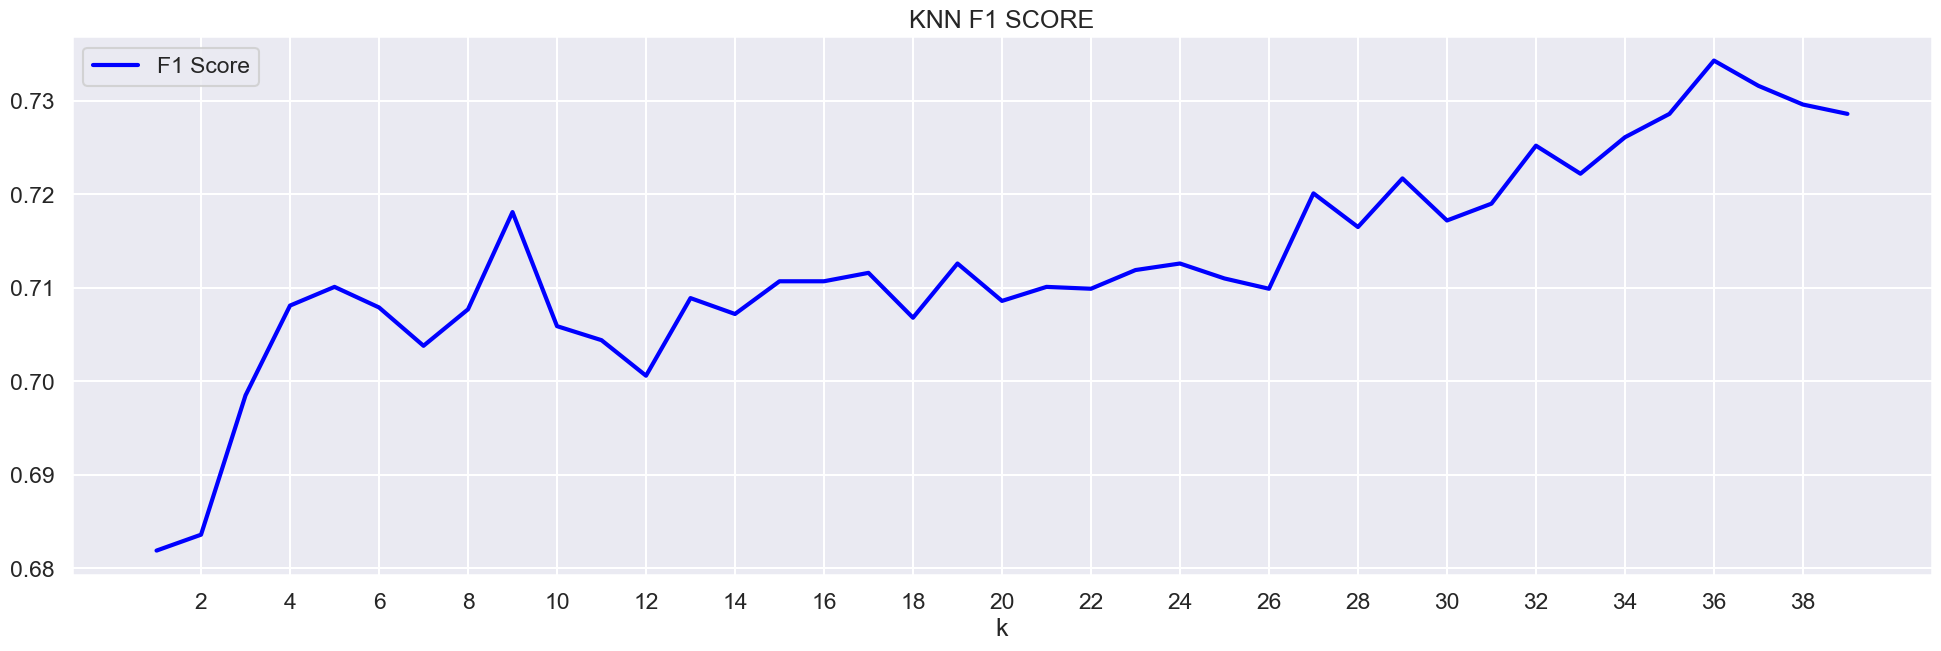

In [36]:
sns.set_context('talk')
sns.set_style('darkgrid')

plt.figure(dpi=300)

ax = f1_result_df.set_index('k').plot(
    color='blue',
    figsize=(24,7),
    linewidth=3
)

ax.set_xticks(range(2, max_k, 2))
plt.title('KNN F1 SCORE')
plt.grid(True)
plt.show()

Text(32.08333333333333, 0.5, 'Grond Truth')

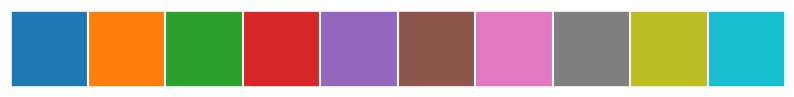

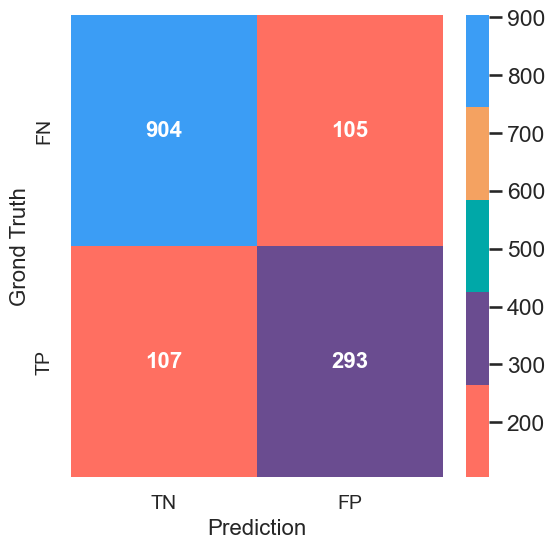

In [40]:
colors = [
    "#FF6F61", "#6A4C90", "#00A8A8", "#F4A261", "#3B9DF5"
]

palette = sns.color_palette(colors)

sns.palplot(sns.color_palette())

_, ax = plt.subplots(figsize=(6, 6))

ax = sns.heatmap(
    confusion_matrix(y_test, y_pred_final),
    annot=True,
    fmt='d',
    cmap=colors,
    annot_kws={
        'size':16,
        'weight':'bold'
    }
)

x_tick_labels = ['TN', 'FP']
y_tick_labels = ['FN', 'TP']

ax.set_xticklabels(x_tick_labels, fontsize=14)
ax.set_yticklabels(y_tick_labels, fontsize=14)
ax.set_xlabel('Prediction', fontsize=16)
ax.set_ylabel('Grond Truth', fontsize=16)